In [2]:
from sklearn.datasets import make_circles

X , y = make_circles(1000,noise=0.03,random_state=42)

In [3]:
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0]
                        ,"X2":X[:,1],
                        "label":y
                        })

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

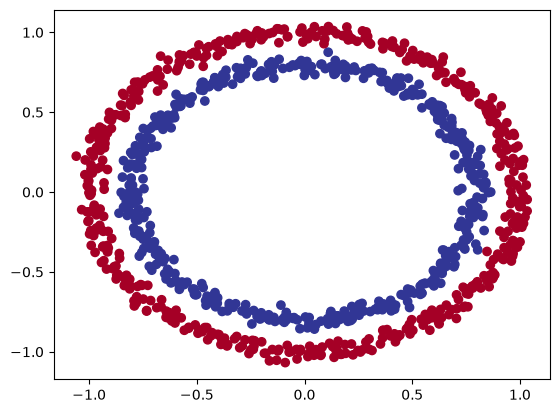

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [7]:
X.shape,y.shape

((1000, 2), (1000,))

In [8]:
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [9]:
import torch 
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,5)
        self.layer2 = nn.Linear(5,1)

    def forward(self,x):
        return self.layer2(self.layer1(x))

Model_0 = CircleModelV0().to(device)
Model_0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
Model_0 = nn.Sequential(
    nn.Linear(2,5),
    nn.Linear(5,1)
).to(device)

Model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(Model_0.parameters(),lr=0.1)

In [15]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc

In [16]:
torch.manual_seed(42)

epochs = 100

X_train,y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    Model_0.train()

    y_logits = Model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_func(y_logits,y_train)
    acc = accuracy_fn(y_train,y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    Model_0.eval()
    with torch.inference_mode():
        test_logits = Model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss= loss_func(test_logits,y_test)
        test_acc = accuracy_fn(y_test,test_pred)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70334, Accuracy: 48.66% | Test loss: 0.69181, Test acc: 52.73%
Epoch: 10 | Loss: 0.69884, Accuracy: 46.87% | Test loss: 0.69074, Test acc: 46.97%
Epoch: 20 | Loss: 0.69655, Accuracy: 44.78% | Test loss: 0.69087, Test acc: 50.61%
Epoch: 30 | Loss: 0.69527, Accuracy: 47.16% | Test loss: 0.69135, Test acc: 51.21%
Epoch: 40 | Loss: 0.69448, Accuracy: 47.91% | Test loss: 0.69191, Test acc: 51.21%
Epoch: 50 | Loss: 0.69395, Accuracy: 48.81% | Test loss: 0.69243, Test acc: 52.73%
Epoch: 60 | Loss: 0.69358, Accuracy: 49.10% | Test loss: 0.69290, Test acc: 53.64%
Epoch: 70 | Loss: 0.69330, Accuracy: 52.39% | Test loss: 0.69331, Test acc: 51.21%
Epoch: 80 | Loss: 0.69310, Accuracy: 59.10% | Test loss: 0.69369, Test acc: 54.85%
Epoch: 90 | Loss: 0.69294, Accuracy: 51.34% | Test loss: 0.69402, Test acc: 47.27%


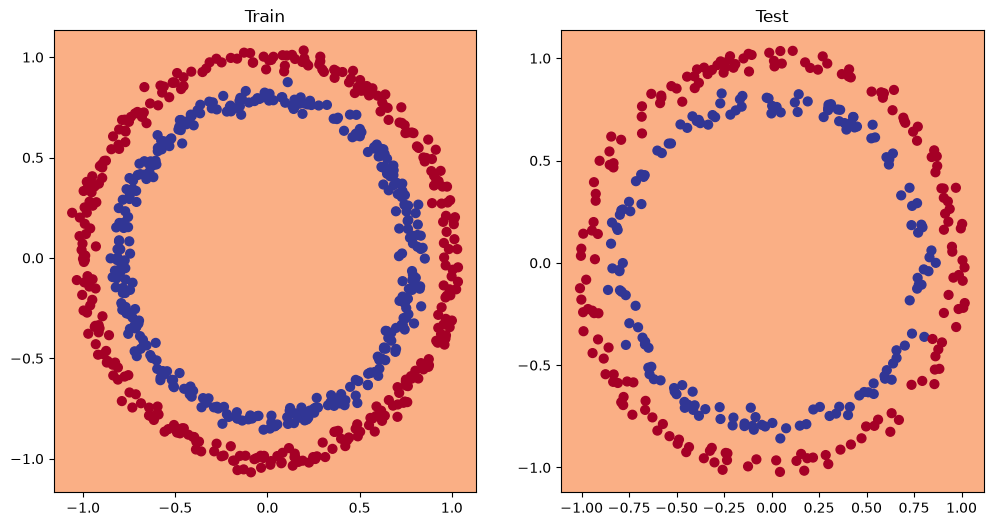

In [17]:
from helper_functions import plot_decision_boundary , plot_predictions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_0,X_train,y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_0,X_test,y_test)

In [18]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,10)
        self.layer2 = nn.Linear(10,10)
        self.layer3 = nn.Linear(10,1)

    def forward(self,x):
        return self.layer3(self.layer2(self.layer1(x)))

Model_1 = CircleModelV1()
Model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [21]:
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(Model_1.parameters(),lr=0.1)

In [22]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    Model_1.train()

    y_logits = Model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_func(y_logits,y_train)
    acc = accuracy_fn(y_train,y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    Model_1.eval()
    with torch.inference_mode():
        test_logits = Model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_func(test_logits,y_test)
        test_acc = accuracy_fn(y_test,test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")





Epoch: 0 | Loss: 0.69355, Accuracy: 51.34% | Test loss: 0.69404, Test acc: 49.70%
Epoch: 100 | Loss: 0.69248, Accuracy: 57.76% | Test loss: 0.69611, Test acc: 51.21%
Epoch: 200 | Loss: 0.69240, Accuracy: 57.16% | Test loss: 0.69673, Test acc: 52.42%
Epoch: 300 | Loss: 0.69239, Accuracy: 55.52% | Test loss: 0.69697, Test acc: 49.70%
Epoch: 400 | Loss: 0.69239, Accuracy: 55.07% | Test loss: 0.69706, Test acc: 50.30%
Epoch: 500 | Loss: 0.69239, Accuracy: 54.93% | Test loss: 0.69709, Test acc: 49.70%
Epoch: 600 | Loss: 0.69239, Accuracy: 54.93% | Test loss: 0.69710, Test acc: 50.00%
Epoch: 700 | Loss: 0.69238, Accuracy: 54.93% | Test loss: 0.69711, Test acc: 50.30%
Epoch: 800 | Loss: 0.69239, Accuracy: 55.07% | Test loss: 0.69711, Test acc: 50.30%
Epoch: 900 | Loss: 0.69238, Accuracy: 55.07% | Test loss: 0.69711, Test acc: 50.30%


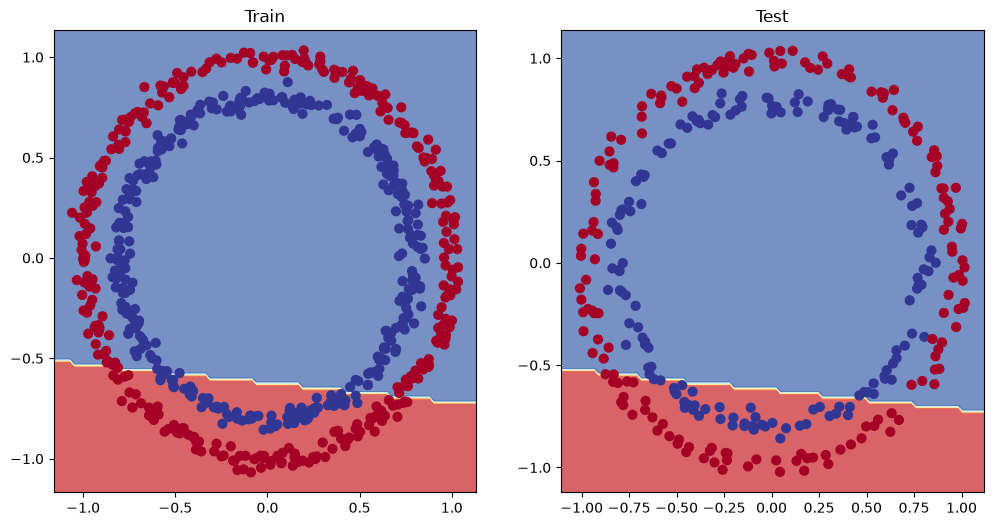

In [23]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_1, X_test, y_test)

In [26]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start,end,step).unsqueeze(1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5],y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [27]:
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


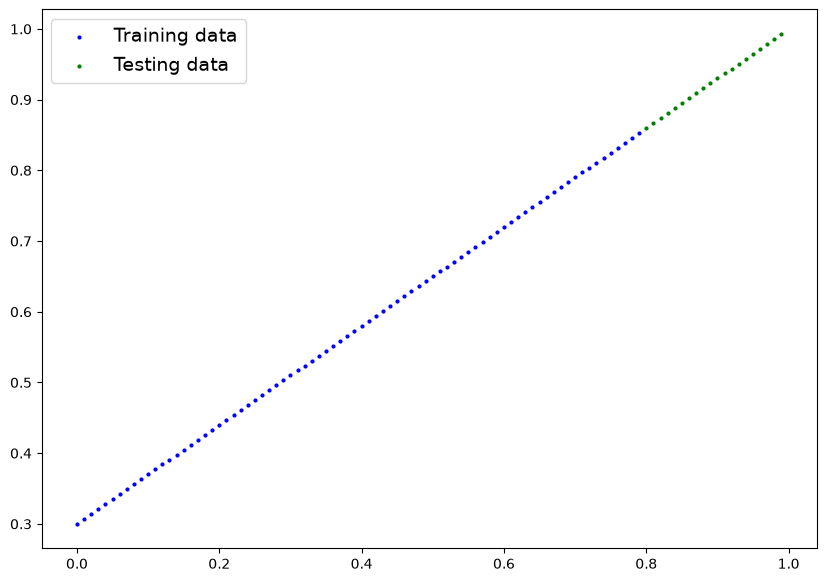

In [28]:
plot_predictions(X_train_regression,y_train_regression,X_test_regression,y_test_regression)

In [32]:
Model_2 = nn.Sequential(
    nn.Linear(1,10),
    nn.Linear(10,10),
    nn.Linear(10,1)
).to(device)
Model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [33]:
loss_func = nn.L1Loss()
optimizer = torch.optim.SGD(Model_2.parameters(),lr=0.1)

In [37]:
torch.manual_seed(42)
epochs =1000
X_train_regression,X_test_regression=X_train_regression.to(device),X_test_regression.to(device)
y_train_regression,y_test_regression=y_train_regression.to(device),y_test_regression.to(device)

for epoch in range(epochs):
    Model_2.train()
    y_pred = Model_2(X_train_regression)

    loss = loss_func(y_pred,y_train_regression)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    Model_2.eval()
    with torch.inference_mode():
        test_pred = Model_2(X_test_regression)
        test_loss = loss_func(test_pred, y_test_regression)
    if epoch % 100 == 0:
        print(f"epoch: {epoch} | loss: {loss:.5f} , test_loss:{test_loss} ")

epoch: 0 | loss: 0.04708 , test_loss:0.01396232284605503 
epoch: 100 | loss: 0.05332 , test_loss:0.006611162330955267 
epoch: 200 | loss: 0.06768 , test_loss:0.01902792975306511 
epoch: 300 | loss: 0.05847 , test_loss:0.020191799849271774 
epoch: 400 | loss: 0.06437 , test_loss:0.025198061019182205 
epoch: 500 | loss: 0.06197 , test_loss:0.016995485872030258 
epoch: 600 | loss: 0.05815 , test_loss:0.02209572121500969 
epoch: 700 | loss: 0.05531 , test_loss:0.014092817902565002 
epoch: 800 | loss: 0.04384 , test_loss:0.02526772953569889 
epoch: 900 | loss: 0.05293 , test_loss:0.013757291249930859 


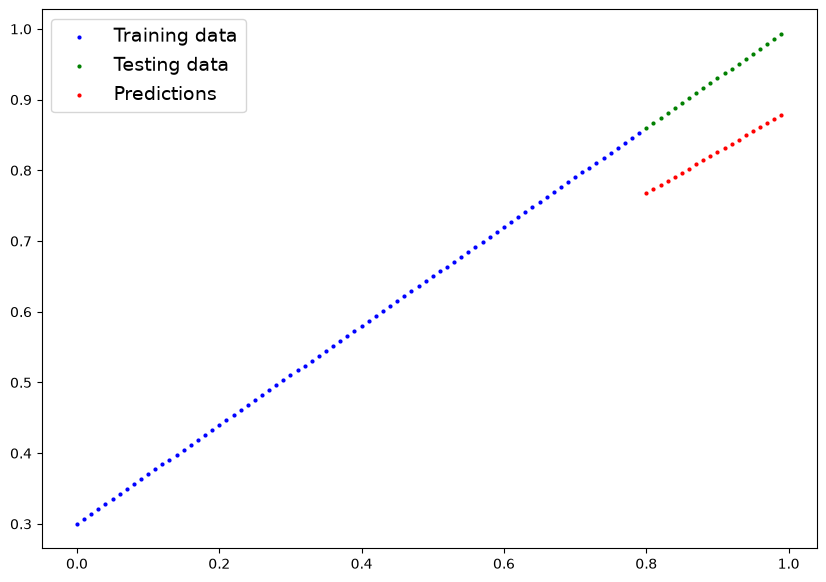

In [47]:

# Turn on evaluation mode
Model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = Model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())

In [51]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,10)
        self.layer2 = nn.Linear(10,10)
        self.layer3 = nn.Linear(10,1)
        self.relu = nn.ReLU()

    def forward(self,x):
        return (self.layer3(self.relu(self.layer2(self.relu(self.layer1(x))))))

Model_3 = CircleModelV2()
Model_3


CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [57]:
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(Model_3.parameters(),lr=0.3)

In [58]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    Model_3.train()

    y_logits = Model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_func(y_logits,y_train)
    acc = accuracy_fn(y_train,y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    Model_3.eval()
    with torch.inference_mode():
        test_logits = Model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_func(test_logits,y_test)
        test_acc = accuracy_fn(y_test,test_pred)

    if epoch % 100 == 0:
        print(f"epoch: {epoch} | loss: {loss:.5f} , test_loss:{test_loss:.5f} | acc:{acc}, test_acc:{test_acc}")


epoch: 0 | loss: 0.57213 , test_loss:0.58560 | acc:84.4776119402985, test_acc:83.93939393939394
epoch: 100 | loss: 0.49772 , test_loss:0.60629 | acc:62.089552238805965, test_acc:59.696969696969695
epoch: 200 | loss: 0.30005 , test_loss:0.38855 | acc:84.92537313432837, test_acc:78.48484848484848
epoch: 300 | loss: 0.06463 , test_loss:0.08707 | acc:99.85074626865672, test_acc:99.39393939393939
epoch: 400 | loss: 0.03670 , test_loss:0.05652 | acc:100.0, test_acc:99.39393939393939
epoch: 500 | loss: 0.02533 , test_loss:0.04360 | acc:100.0, test_acc:99.39393939393939
epoch: 600 | loss: 0.01922 , test_loss:0.03638 | acc:100.0, test_acc:99.39393939393939
epoch: 700 | loss: 0.01544 , test_loss:0.03179 | acc:100.0, test_acc:99.39393939393939
epoch: 800 | loss: 0.01288 , test_loss:0.02864 | acc:100.0, test_acc:99.39393939393939
epoch: 900 | loss: 0.01104 , test_loss:0.02633 | acc:100.0, test_acc:99.39393939393939


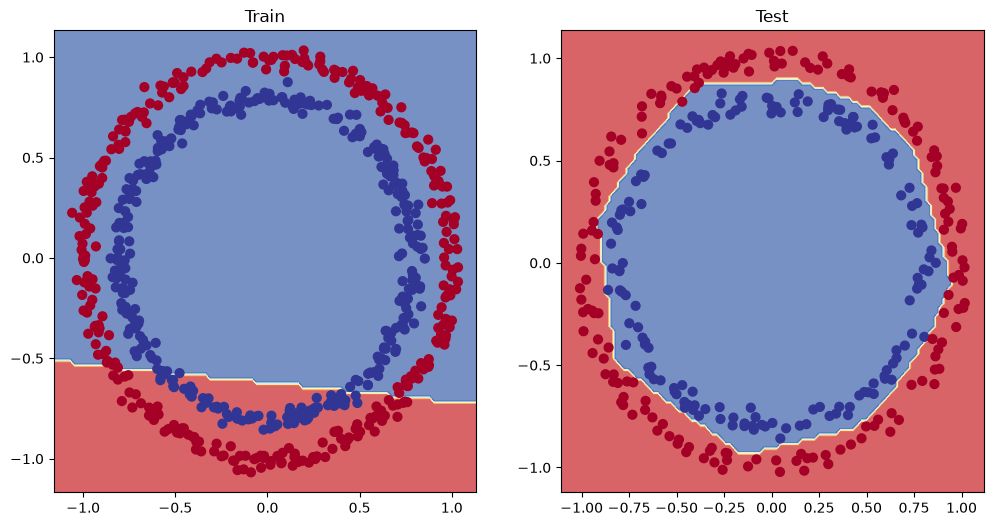

In [59]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_3, X_test, y_test)

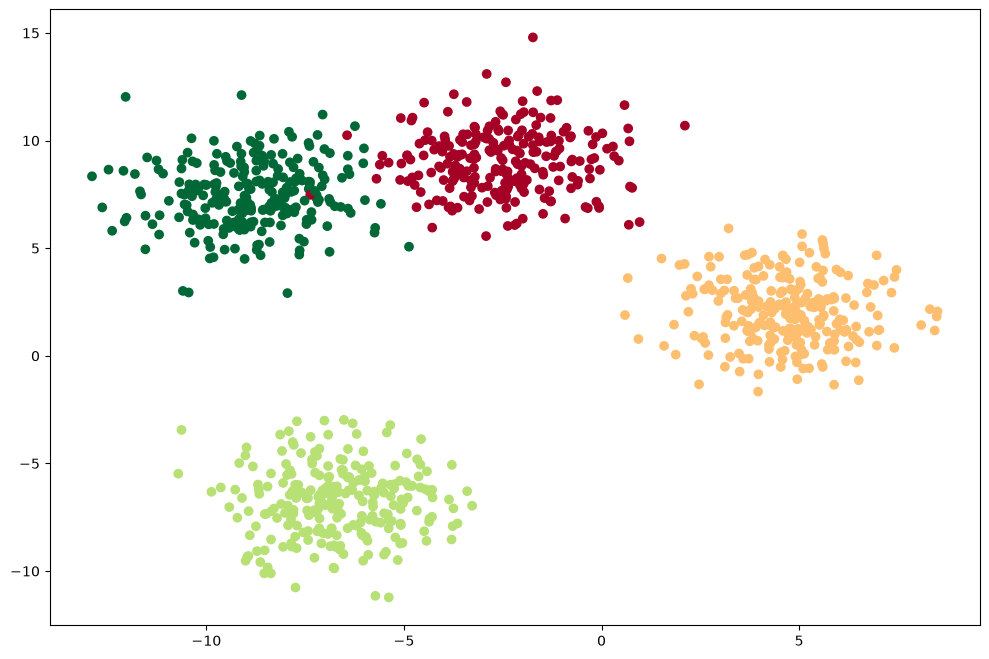

In [5]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

x_blob,y_blob = make_blobs(1000,2,centers=4,cluster_std=1.5,random_state=42)

x_blob = torch.from_numpy(x_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(x_blob, y_blob, test_size=0.33, random_state=42)

plt.figure(figsize=(12,8))
plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob,cmap=plt.cm.RdYlGn)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [11]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self,input_feature,output_feature,hidden_unit):
        super().__init__()
        self.layer1 = nn.Linear(input_feature,hidden_unit)
        self.layer2 = nn.Linear(hidden_unit,hidden_unit)
        self.layer3 = nn.Linear(hidden_unit,output_feature)

    def forward(self,x):
        return self.layer3(self.layer2(self.layer1(x)))

Model_4 = BlobModel(2,4,8)
Model_4

BlobModel(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=4, bias=True)
)

In [ ]:
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(Model_4.parameters(),lr=0.1)

In [15]:
Model_4(X_train)[:5]

tensor([[ 0.7242, -2.8227, -1.3221, -2.0149],
        [-0.9509,  0.8449,  0.3470,  1.3294],
        [ 0.6808, -2.4051, -1.1133, -1.7189],
        [ 0.2168,  0.7710,  0.4579,  0.6092],
        [-1.0151,  0.6303,  0.2286,  1.2272]], grad_fn=<SliceBackward0>)

In [17]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc

In [19]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    Model_4.train()

    y_logits = Model_4(X_train)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_func(y_logits,y_train)
    acc = accuracy_fn(y_train,y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    Model_4.eval()
    with torch.inference_mode():
        test_logits = Model_4(X_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

        test_loss = loss_func(test_logits,y_test)
        test_acc = accuracy_fn(y_test,test_pred)

    if epoch % 10 == 0:
        print(f"epoch: {epoch} |loss:{loss:.5f},test_loss:{test_loss:.5f} |acc :{acc:.2f}% , test_acc:{test_acc:.2f}%")


epoch: 0 |loss:0.74080,test_loss:0.59510 |acc :68.21% , test_acc:73.64%
epoch: 10 |loss:0.15830,test_loss:0.14132 |acc :99.10% , test_acc:99.09%
epoch: 20 |loss:0.08735,test_loss:0.07908 |acc :99.25% , test_acc:99.09%
epoch: 30 |loss:0.06370,test_loss:0.05639 |acc :99.40% , test_acc:99.09%
epoch: 40 |loss:0.05236,test_loss:0.04505 |acc :99.40% , test_acc:99.09%
epoch: 50 |loss:0.04584,test_loss:0.03836 |acc :99.40% , test_acc:99.09%
epoch: 60 |loss:0.04166,test_loss:0.03396 |acc :99.40% , test_acc:99.09%
epoch: 70 |loss:0.03877,test_loss:0.03087 |acc :99.40% , test_acc:99.09%
epoch: 80 |loss:0.03667,test_loss:0.02858 |acc :99.40% , test_acc:99.09%
epoch: 90 |loss:0.03509,test_loss:0.02681 |acc :99.40% , test_acc:99.09%


In [23]:
from helper_functions import plot_decision_boundary

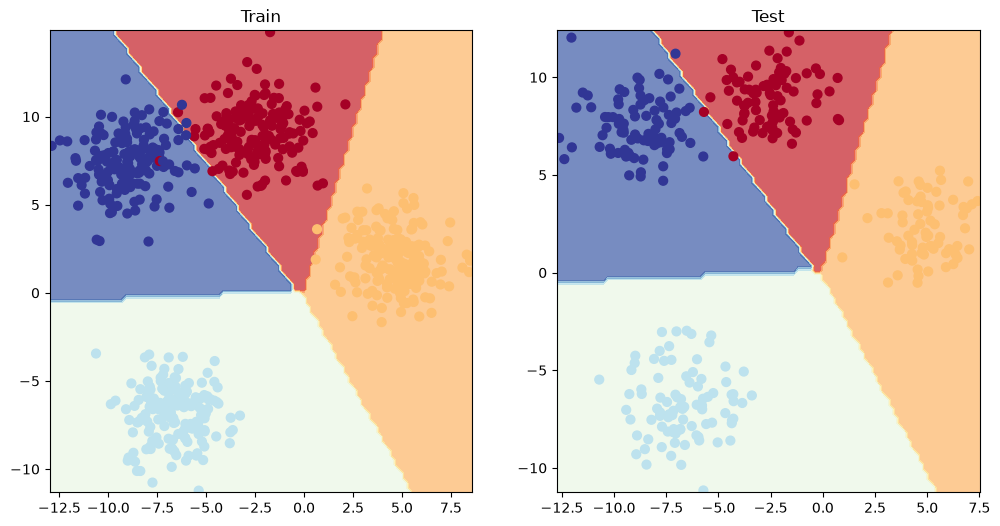

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_4, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_4, X_test, y_test)

In [28]:
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(y_test,test_pred)

cf

array([[81,  0,  0,  2],
       [ 0, 73,  0,  0],
       [ 0,  0, 88,  0],
       [ 1,  0,  0, 85]])

<Axes: >

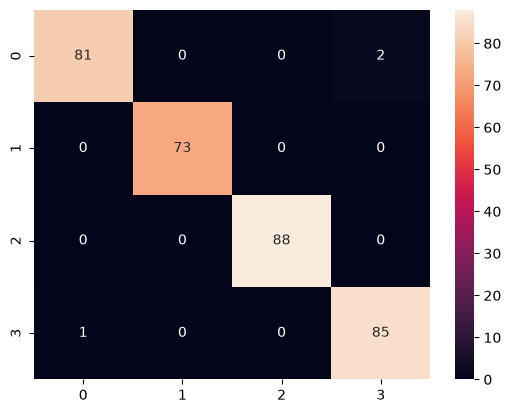

In [29]:
import seaborn as sns 
sns.heatmap(cf,annot=True)